In [6]:
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

In [7]:
import os
root_path = r"C:\gtsrb_data"
os.makedirs(root_path, exist_ok=True)

In [8]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])
train_dataset = datasets.GTSRB(root=root_path, split="train", download=True, transform=transform)
test_dataset  = datasets.GTSRB(root=root_path, split="test",  download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=len(train_dataset), shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=len(test_dataset),  shuffle=False)
X_train_full, y_train_full = next(iter(train_loader))
X_test, y_test = next(iter(test_loader))

100%|██████████| 187M/187M [00:20<00:00, 9.18MB/s]
100%|██████████| 89.0M/89.0M [00:09<00:00, 9.18MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 151kB/s]


In [9]:
X_train_full = X_train_full.permute(0, 2, 3, 1).numpy()
y_train_full = y_train_full.numpy()
X_test = X_test.permute(0, 2, 3, 1).numpy()
y_test = y_test.numpy()
print(f"raw data train: {X_train_full.shape}, test: {X_test.shape}")


raw data train: (26640, 32, 32, 3), test: (12630, 32, 32, 3)


In [10]:
def clean_data(X, y):
    brightness = X.mean(axis=(1, 2, 3))
    mask = (brightness > 0.05) & (brightness < 0.95)

    variance = X.var(axis=(1, 2, 3))
    mask &= variance > 1e-4

    return X[mask], y[mask]

X_train_full, y_train_full = clean_data(X_train_full, y_train_full)
X_test, y_test = clean_data(X_test, y_test)

print(f"clean data  train: {X_train_full.shape}, test: {X_test.shape}")

clean data  train: (26384, 32, 32, 3), test: (12574, 32, 32, 3)


In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15,
    stratify=y_train_full,
    random_state=42
)
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (22426, 32, 32, 3), Val: (3958, 32, 32, 3), Test: (12574, 32, 32, 3)


In [12]:
num_classes = 43
y_train_cat = to_categorical(y_train, num_classes)
y_val_cat   = to_categorical(y_val, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

In [13]:
'''change'''
import tensorflow as tf
from tensorflow.keras import layers, models

def build_gtsrb_model(input_shape=(32, 32, 3), num_classes=43):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)
    return model
model = build_gtsrb_model(num_classes=43)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 1,361,995 (5.20 MB)

 Trainable params: 1,360,075 (5.19 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [14]:
initial_learning_rate = 1e-3
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

In [15]:
model.compile(
    optimizer= optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)
]

In [17]:
'''change'''
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1,
    fill_mode='nearest'
)

In [18]:
'''change'''
history = model.fit(
    train_datagen.flow(X_train, y_train_cat, batch_size=64),
    validation_data=(X_val, y_val_cat),
    epochs=30,
    steps_per_epoch=len(X_train) // 64 ,
    callbacks=callbacks
)


Epoch 1/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 43s 79ms/step - accuracy: 0.3083 - loss: 2.6207 - val_accuracy: 0.3618 - val_loss: 2.2191 - learning_rate: 0.0010
Epoch 2/30
  1/350 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.5469 - loss: 1.3415

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5469 - loss: 1.3415 - val_accuracy: 0.3570 - val_loss: 2.2502 - learning_rate: 0.0010
Epoch 3/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.7310 - loss: 0.8367 - val_accuracy: 0.9368 - val_loss: 0.2142 - learning_rate: 0.0010
Epoch 4/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8125 - loss: 0.4461 - val_accuracy: 0.9282 - val_loss: 0.2257 - learning_rate: 0.0010
Epoch 5/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 16s 47ms/step - accuracy: 0.8729 - loss: 0.3924 - val_accuracy: 0.9709 - val_loss: 0.0873 - learning_rate: 0.0010
Epoch 6/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8750 - loss: 0.3098 - val_accuracy: 0.9757 - val_loss: 0.0767 - learning_rate: 0.0010
Epoch 7/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 17s 48ms/step - accuracy: 0.9254 - loss: 0.2349 - val_accuracy: 0.9889 - val_loss: 0.0395 - learning_rate: 0.0010
Epoch 8/30
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9219 - loss: 0.2975 - val_a

In [19]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print(f"Test accuracy : {test_acc*100:.2f}%")

393/393 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9800 - loss: 0.0576
Test accuracy : 98.00%


In [20]:
from tensorflow.keras.models import load_model
from PIL import Image
import cv2
def predict_image(image_path, img_size=32):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((img_size, img_size))
    img_array = np.array(img).astype("float32") / 255.0

    img_array = np.expand_dims(img_array, axis=0)
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class]
    display(img)
    return predicted_class, confidence



In [21]:
from google.colab import files

print("Please upload the image you want to predict:")
uploaded = files.upload()

Please upload the image you want to predict:


Saving lily-pearson-8dPqrXZ-GJI-unsplash.jpg to lily-pearson-8dPqrXZ-GJI-unsplash.jpg


Once the image is uploaded, you can get its filename from the `uploaded` dictionary. For example, if you uploaded `my_image.jpg`, the filename would be `list(uploaded.keys())[0]` or just `'my_image.jpg'` if you know the name.

In [24]:
CLASS_NAMES = {
    0: "Speed limit (20km/h)", 1: "Speed limit (30km/h)", 2: "Speed limit (50km/h)",
    3: "Speed limit (60km/h)", 4: "Speed limit (70km/h)", 5: "Speed limit (80km/h)",
    6: "End of speed limit (80km/h)", 7: "Speed limit (100km/h)", 8: "Speed limit (120km/h)",
    9: "No passing", 10: "No passing (vehicles > 3.5t)", 11: "Right-of-way at intersection",
    12: "Priority road", 13: "Yield", 14: "Stop", 15: "No vehicles",
    16: "Vehicles > 3.5t prohibited", 17: "No entry", 18: "General caution",
    19: "Dangerous curve left", 20: "Dangerous curve right", 21: "Double curve",
    22: "Bumpy road", 23: "Slippery road", 24: "Road narrows on the right",
    25: "Road work", 26: "Traffic signals", 27: "Pedestrians", 28: "Children crossing",
    29: "Bicycles crossing", 30: "Beware of ice/snow", 31: "Wild animals crossing",
    32: "End speed + passing limits", 33: "Turn right ahead", 34: "Turn left ahead",
    35: "Ahead only", 36: "Go straight or right", 37: "Go straight or left",
    38: "Keep right", 39: "Keep left", 40: "Roundabout mandatory",
    41: "End of no passing", 42: "End no passing (vehicles > 3.5t)"
}


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


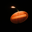

sign: No entry (52.80%)


In [23]:
uploaded_filename = list(uploaded.keys())[0]
class_id, conf = predict_image(uploaded_filename)
print(f"sign: {CLASS_NAMES[class_id]} ({conf:.2%})")